In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Практические задания

#### 1. Численная производная. Реализуйте derivative(f, x) через прямую и центральную разности. Проверьте на 5 функциях из таблицы. Какая ошибка меньше при h=1e-5?

In [12]:
def forward_derivative(f, x, h=1e-5):
    # Прямая разность
    if h < 1e-12:
        raise ValueError("h слишком мал: возможны ошибки округления")
    return (f(x + h) - f(x)) / h

def central_derivative(f, x, h=1e-5):
    # Центральная разность
    if h < 1e-12:
        raise ValueError("h слишком мал: возможны ошибки округления")
    return(f(x + h) - f(x - h)) / (2 * h)

# Пример проверки на функции из таблицы
functions = [
    lambda x: x**2,         # x^n (n=2)
    lambda x: math.exp(x),  # e^x
    lambda x: math.log(x),  # ln(x)
    lambda x: math.sin(x),  # sin(x)
    lambda x: math.cos(x)   # cos(x)
]

analytical_derivatives = [
    lambda x: 2*x,          # 2x
    lambda x: math.exp(x),  # e^x
    lambda x: 1 / x,        # 1/x
    lambda x: math.cos(x),  # cos(x)
    lambda x: -math.sin(x)  # -sin(x)
]

for i, func in enumerate(functions):
    x = 1.0  # Точка для проверки
    fd = forward_derivative(func, x)
    cd = central_derivative(func, x)
    exact = analytical_derivatives[i](x)

    print(f"Функция {i+1}:")
    print(f"  forward error: {abs(fd - exact)}")
    print(f"  central error: {abs(cd - exact)}")

Функция 1:
  forward error: 1.0000013929811757e-05
  central error: 2.000177801164682e-12
Функция 2:
  forward error: 1.3591497672216235e-05
  central error: 5.858691309867936e-11
Функция 3:
  forward error: 4.99996011593673e-06
  central error: 3.4333202947323116e-11
Функция 4:
  forward error: 4.207362275021609e-06
  central error: 1.1140866007508521e-11
Функция 5:
  forward error: 2.7015114750783553e-06
  central error: 1.086408740746947e-11


##### Центральная разность выдает ошибку на порядки меньше прямой (особенно для гладких функций)

#### 2. Производная сигмоиды. Аналитически выведите σ'(x) = σ(x)(1-σ(x)). Проверьте численно для 100 точек.

In [5]:
def sigmoid(x):
    # Сигмоида: σ(x) = 1 / (1 + e^(-x))
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative_analytical(x):
    # Аналитическая производная сигмоиды: σ'(x) = σ(x) * (1 - σ(x))
    return sigmoid(x) * (1 - sigmoid(x))

def central_derivative(f, x, h=1e-5):
    # Численная производная через центральную разность:
    # f'(x) ≈ (f(x + h) - f(x - h)) / (2h)
    return (f(x + h) - f(x - h)) / (2 * h)

errors = []  # Список для накопления ошибок на каждой точке

# Проверяем производную в точках от -5 до 4

points = np.linspace(-5, 5, 100)  # 100 точек от -5 до 5
for x in points:

    # Численная производная (приближённое значение)
    num_deriv = central_derivative(sigmoid, x)

    # Аналитическая производная (точное значение)
    anal_deriv = sigmoid_derivative_analytical(x)

    # Абсолютная ошибка между численным и точным значением
    error = abs(num_deriv - anal_deriv)
    errors.append(error)  # Сохраняем ошибку

# Средняя ошибка по всем точкам
mean_error = np.mean(errors)
print(f"Средняя ошибка: {mean_error:.2e}")

# Проверка: численная производная должна совпадать с аналитической
assert np.isclose(mean_error, 0, atol=1e-10), "Ошибка превышает допустимый порог"

Средняя ошибка: 2.37e-12


#### 3. Свой градиент. Реализуйте grad(f, x) для функции от вектора. Проверьте на f(x) = ||x||² = sum(x²). Ожидается 2x.

In [9]:
def grad(f, x, h=1e-5):
    # Слишком маленький шаг может привести к ошибкам округления
    if h < 1e-12:
        raise ValueError("h слишком мал: возможны ошибки округдения")
    
    # Преобразуем x в массив NumPy типа float
    x = np.asarray(x, dtype=float)

    # Создаём нулевой вектор для хранения значений градиента
    x_grad = np.zeros_like(x)
    
    # Последовательно вычисляем каждую частную производную
    for i in range(len(x)):
        # Создаём единичный вектор e_i:
        e_i = np.zeros_like(x)
        e_i[i] = 1.0  # на позиции i стоит 1, на остальных позициях — 0
        
        # Смещаем точку x в положительном и отрицательном направлениях
        x_plus = x + h * e_i
        x_minus = x - h * e_i
        
        # Центральная разностная аппроксимация производной
        x_grad[i] = (f(x_plus) - f(x_minus)) / (2 * h)

    # Возвращаем вычисленный градиент
    return x_grad

# Точка, в которой вычисляется градиент
x = np.array([1.0, 2.0, 0.0, 3.0])

# Численный градиент функции f(x) = сумма квадратов компонент x
numerical_grad = grad(lambda v: np.sum(v**2), x)
# Аналитический градиент функции
analytical_grad = 2 * x

# Вычисляем евклидово расстояние между двумя градиентами
error = np.linalg.norm(numerical_grad - analytical_grad)

# Выводим результаты
print("Численный градиент: ", numerical_grad)
print("Аналитический градиент: ", analytical_grad)
print(f"Ошибка: {error:.2e}")

# Проверяем, что относительная ошибка достаточно мала
relative_error = error / np.linalg.norm(analytical_grad)
assert relative_error < 1e-8, "Относительная ошибка слишком велика"

Численный градиент:  [2. 4. 0. 6.]
Аналитический градиент:  [2. 4. 0. 6.]
Ошибка: 1.12e-10


#### 4. Линия уровня и градиент. Постройте контурный график f(x, y) = x² + 3y². В 5 точках нарисуйте стрелки антиградиента. Убедитесь, что стрелки указывают к минимуму.

Точка (1, 1), антиградиент = (-2, -6)
Точка (2, 1), антиградиент = (-4, -6)
Точка (-1, 1), антиградиент = (2, -6)
Точка (-2, 1), антиградиент = (4, -6)
Точка (1, -1), антиградиент = (-2, 6)


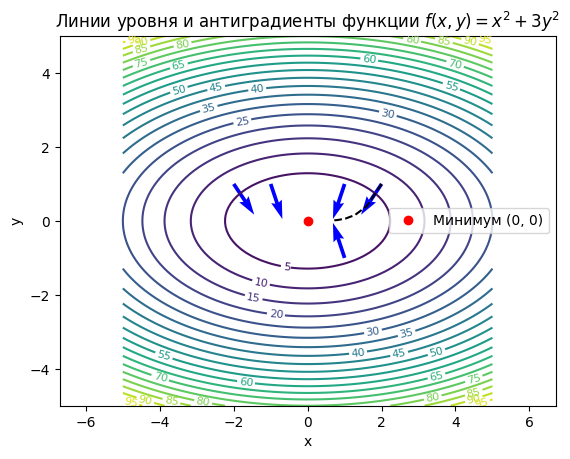

In [22]:
# Определяем функцию f(x, y) = x² + 3y²
def f(x, y):
    return x**2 + 3 * y**2

# Создаём диапазоны значений x и y
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

# Формируем двумерную сетку координат
X, Y = np.meshgrid(x, y)

# Вычисляем значения функции во всех точках сетки
Z = f(X, Y)  

# Строим контурный график
contour = plt.contour(X, Y, Z, levels=20)  # 20 линий уровня

# Добавляем подписи к линиям уровня
plt.clabel(contour, inline=True, fontsize=8)

# Задаём точки, в которых будут нарисованы стрелки
points = [(1, 1), (2, 1), (-1, 1), (-2, 1), (1, -1)]

# Обрабатываем каждую точку
for x0, y0 in points:
    # Вычисляем градиент:
    grad_x = 2 * x0
    grad_y = 6 * y0

    # Антиградиент направлен в сторону уменьшения функции
    anti_grad_x = -grad_x
    anti_grad_y = -grad_y

    # Проверка: печатаем координаты и антиградиент
    print(
        f"Точка ({x0}, {y0}), "
        f"антиградиент = ({anti_grad_x}, {anti_grad_y})"
    )

    # Рисуем стрелку антиградиента
    norm = np.sqrt(anti_grad_x**2 + anti_grad_y**2)
    plt.quiver(x0, y0, anti_grad_x / norm, anti_grad_y / norm, angles='xy', scale_units='xy', scale=1.0, color='blue')
        
# Отмечаем минимум функции в точке (0, 0)
plt.plot(0, 0, 'ro', label='Минимум (0, 0)')

# Подписываем оси и добавляем заголовок
plt.xlabel('x')
plt.ylabel('y')
plt.title('Линии уровня и антиградиенты функции $f(x,y)=x^2+3y^2$')

# Показываем легенду
plt.legend()

# Устанавливаем одинаковый масштаб по обеим осям
plt.axis('equal')

# Траектория спуска из точки (2, 1)
def gradient_descent(start, lr, step=5):
    x, y = start
    trajectory = [(x, y)]
    for _ in range(step):
        x -= lr * 2 * x
        y -= lr * 6 * y
        trajectory.append((x, y))
    return trajectory
trajectory = gradient_descent(start=(2, 1), lr=0.1, step=5)
xs, ys = zip(*trajectory)
plt.plot(xs, ys, 'k--', label='Траектория спуска')

# Отображаем график
plt.show()

#### 5. GD на параболе. Запустите ваш gradient_descent с разными lr: 0.001, 0.1, 0.5, 1.0. Постройте графики сходимости. Где он расходится?

lr = 0.001: начало = 25.000000, конец = 16.751290, сходится медленно
lr = 0.1: начало = 25.000000, конец = 0.000000, сходится
lr = 0.5: начало = 25.000000, конец = 0.000000, сходится
lr = 1.0: начало = 25.000000, конец = 25.000000, колеблится или не сходится


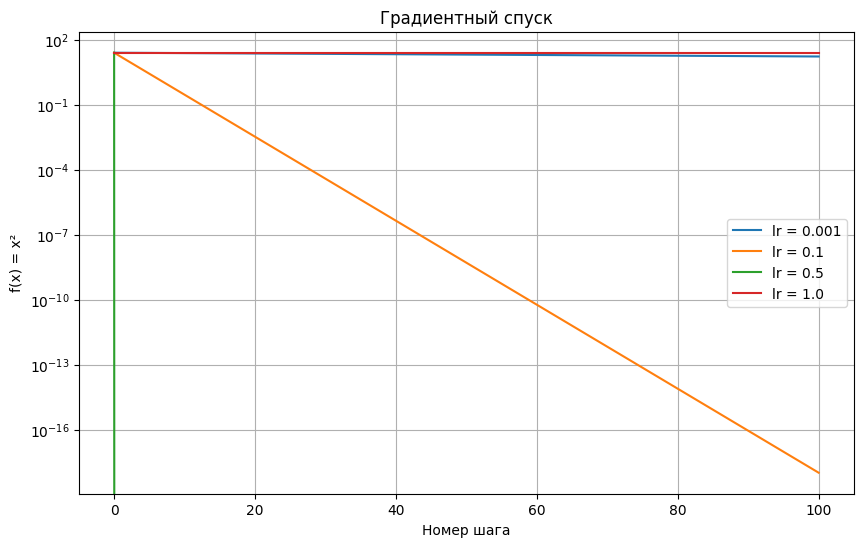

In [4]:
# Целевая функция
def f(x):
    return x**2

# Градиентный спуск
def gradient_descent(f, x0, lr, max_steps=100):
    x = x0
    history = [f(x)]

    for _ in range(max_steps):
        grad = 2 * x          # Производная f(x) = x²
        x = x - lr * grad     # Обновление x
        history.append(f(x))  # Сохраняем значение функции

    return history

# Проверка сходимости
def check_convergence(history, tolerance=1e-10):
    if history[-1] < tolerance:
        return "сходится"

    if history[-1] > history[0]:
        return "расходится"

    if history[-1] >= history[-2]:
        return "колеблится или не сходится"

    return "сходится медленно"

learning_rates = [0.001, 0.1, 0.5, 1.0]
x0 = 5.0
max_steps = 100

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    # Запускаем градиентный спуск
    history = gradient_descent(f, x0, lr, max_steps)

    # Выводим результат
    result = check_convergence(history)
    print(
        f"lr = {lr}: "
        f"начало = {history[0]:.6f}, "
        f"конец = {history[-1]:.6f}, "
        f"{result}"
    )

    # Строим график
    plt.plot(history, label=f"lr = {lr}")

plt.xlabel("Номер шага")
plt.ylabel("f(x) = x²")
plt.title("Градиентный спуск")
plt.yscale("log")  # Логарифмическая шкала
plt.grid(True)
plt.legend()
plt.show()

#### 6. Овраг Розенброка. Запустите GD на функции f(x, y) = (1-x)² + 100(y - x²)². Покажите визуально, как он зигзагит. Сравните с моментом.

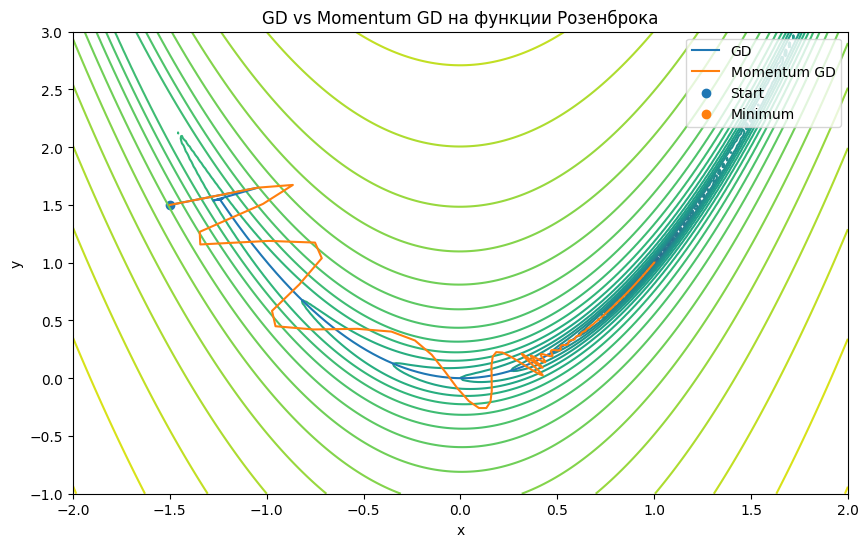

In [17]:
def Rosenbrock(x, y):
    # Функция Розенброка
    return (1 - x)**2 + 100 * (y - x**2)**2

def gradient(x, y):
    # Частные производные функции Розенброка
    dx = 2 * (x - 1) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)

    return dx, dy

def gradient_descent(x0, y0, lr, steps):
    x = x0
    y = y0
    trajectory = [(x, y)]
    
    for _ in range(steps):
        dx, dy = gradient(x, y)
        
        x = x - lr * dx
        y = y - lr * dy

        trajectory.append((x, y))
        
    return trajectory

def momentum_gradient_descent(x0, y0, lr, beta, steps):
    x = x0
    y = y0
    vx = 0
    vy = 0
    trajectory = [(x, y)]
    
    for _ in range(steps):
        dx, dy = gradient(x, y)
        
        vx = beta * vx + lr * dx
        vy = beta * vy + lr * dy
        
        x = x - vx
        y = y - vy

        trajectory.append((x, y))

    return trajectory

# Запуск алгоритмов
x0, y0 = -1.5, 1.5  # Стартовая точка

gd_traj = gradient_descent(x0, y0, lr=0.001, steps=2000)
mom_traj = momentum_gradient_descent(x0, y0, lr=0.001, beta=0.9, steps=2000)

# Распаковка траекторий в координаты x и y
gd_x, gd_y = zip(*gd_traj)
momentum_x, momentum_y = zip(*mom_traj)

# Сетка для контурного графика
xs = np.linspace(-2, 2, 200)
ys = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(xs, ys)
Z = Rosenbrock(X, Y)
epsilon = 1e-10

# Визуализация
plt.figure(figsize=(10, 6))
plt.contour(X, Y, np.log(Z + epsilon), levels=30)
plt.plot(gd_x, gd_y, label="GD")
plt.plot(momentum_x, momentum_y, label="Momentum GD")
plt.scatter(x0, y0, label="Start")
plt.scatter(1, 1, label="Minimum")
plt.legend()
plt.title("GD vs Momentum GD на функции Розенброка")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#### 7. MSE-градиент. Для L(w) = (1/n) Σ (y_i - x_i·w)² выведите градиент по w аналитически и численно. Должно совпасть.

#### 8. Своя линейная регрессия GD. Обучите w на 100 точках с шумом, используя только ваш градиентный спуск. Сравните с np.linalg.solve(X.T @ X, X.T @ y).